In [1]:
from __future__ import annotations
from pathlib import Path 

import yaml, json, os, sys

import numpy as np, matplotlib.pyplot as plt
import igraph as ig, networkx as nx
import torch

from collections import deque 
from matplotlib.ticker import MultipleLocator, FuncFormatter
import matplotlib.colors as mcolors


ROOT = "/scratch/sleonard/MoE_circuits"
sys.path.insert(0, ROOT)

with open(os.path.join(ROOT, "config.yaml")) as f:
    config = yaml.safe_load(f)

MODELS = ["olmoe"]
# MODELS   = ["deepseek-v2", "deepseek-v2-lite", "mixtral-8x7b", "mixtral-8x22b", "qwen3-30b-a3b", "qwen3-235b-a22b", "olmoe", "phi-3.5-moe"]
# MODELS   = ["olmoe", "deepseek-v2-lite", "mixtral-8x7b", "mixtral-8x22b", "qwen3-30b-a3b", "phi-3.5-moe", "qwen3-235b-a22b"]
DATASETS = ["c4"]
# DATASETS = ["c4", "math", "code"]

dags: dict[tuple[str, str], dict] = {}
for m in MODELS:
    for d in DATASETS:
        path = os.path.join(config["result_path"], f"circuits/dag_{m}_{d}.pt")
        dags[(m, d)] = torch.load(path, map_location="cpu")


/scratch/sleonard/miniconda3/envs/megatron/lib/python3.11/site-packages/torch/cuda/__init__.py:61: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]


[VERTEX] olmoe: n_super=2/1024, edges_kept=112, t_vertex=12.5


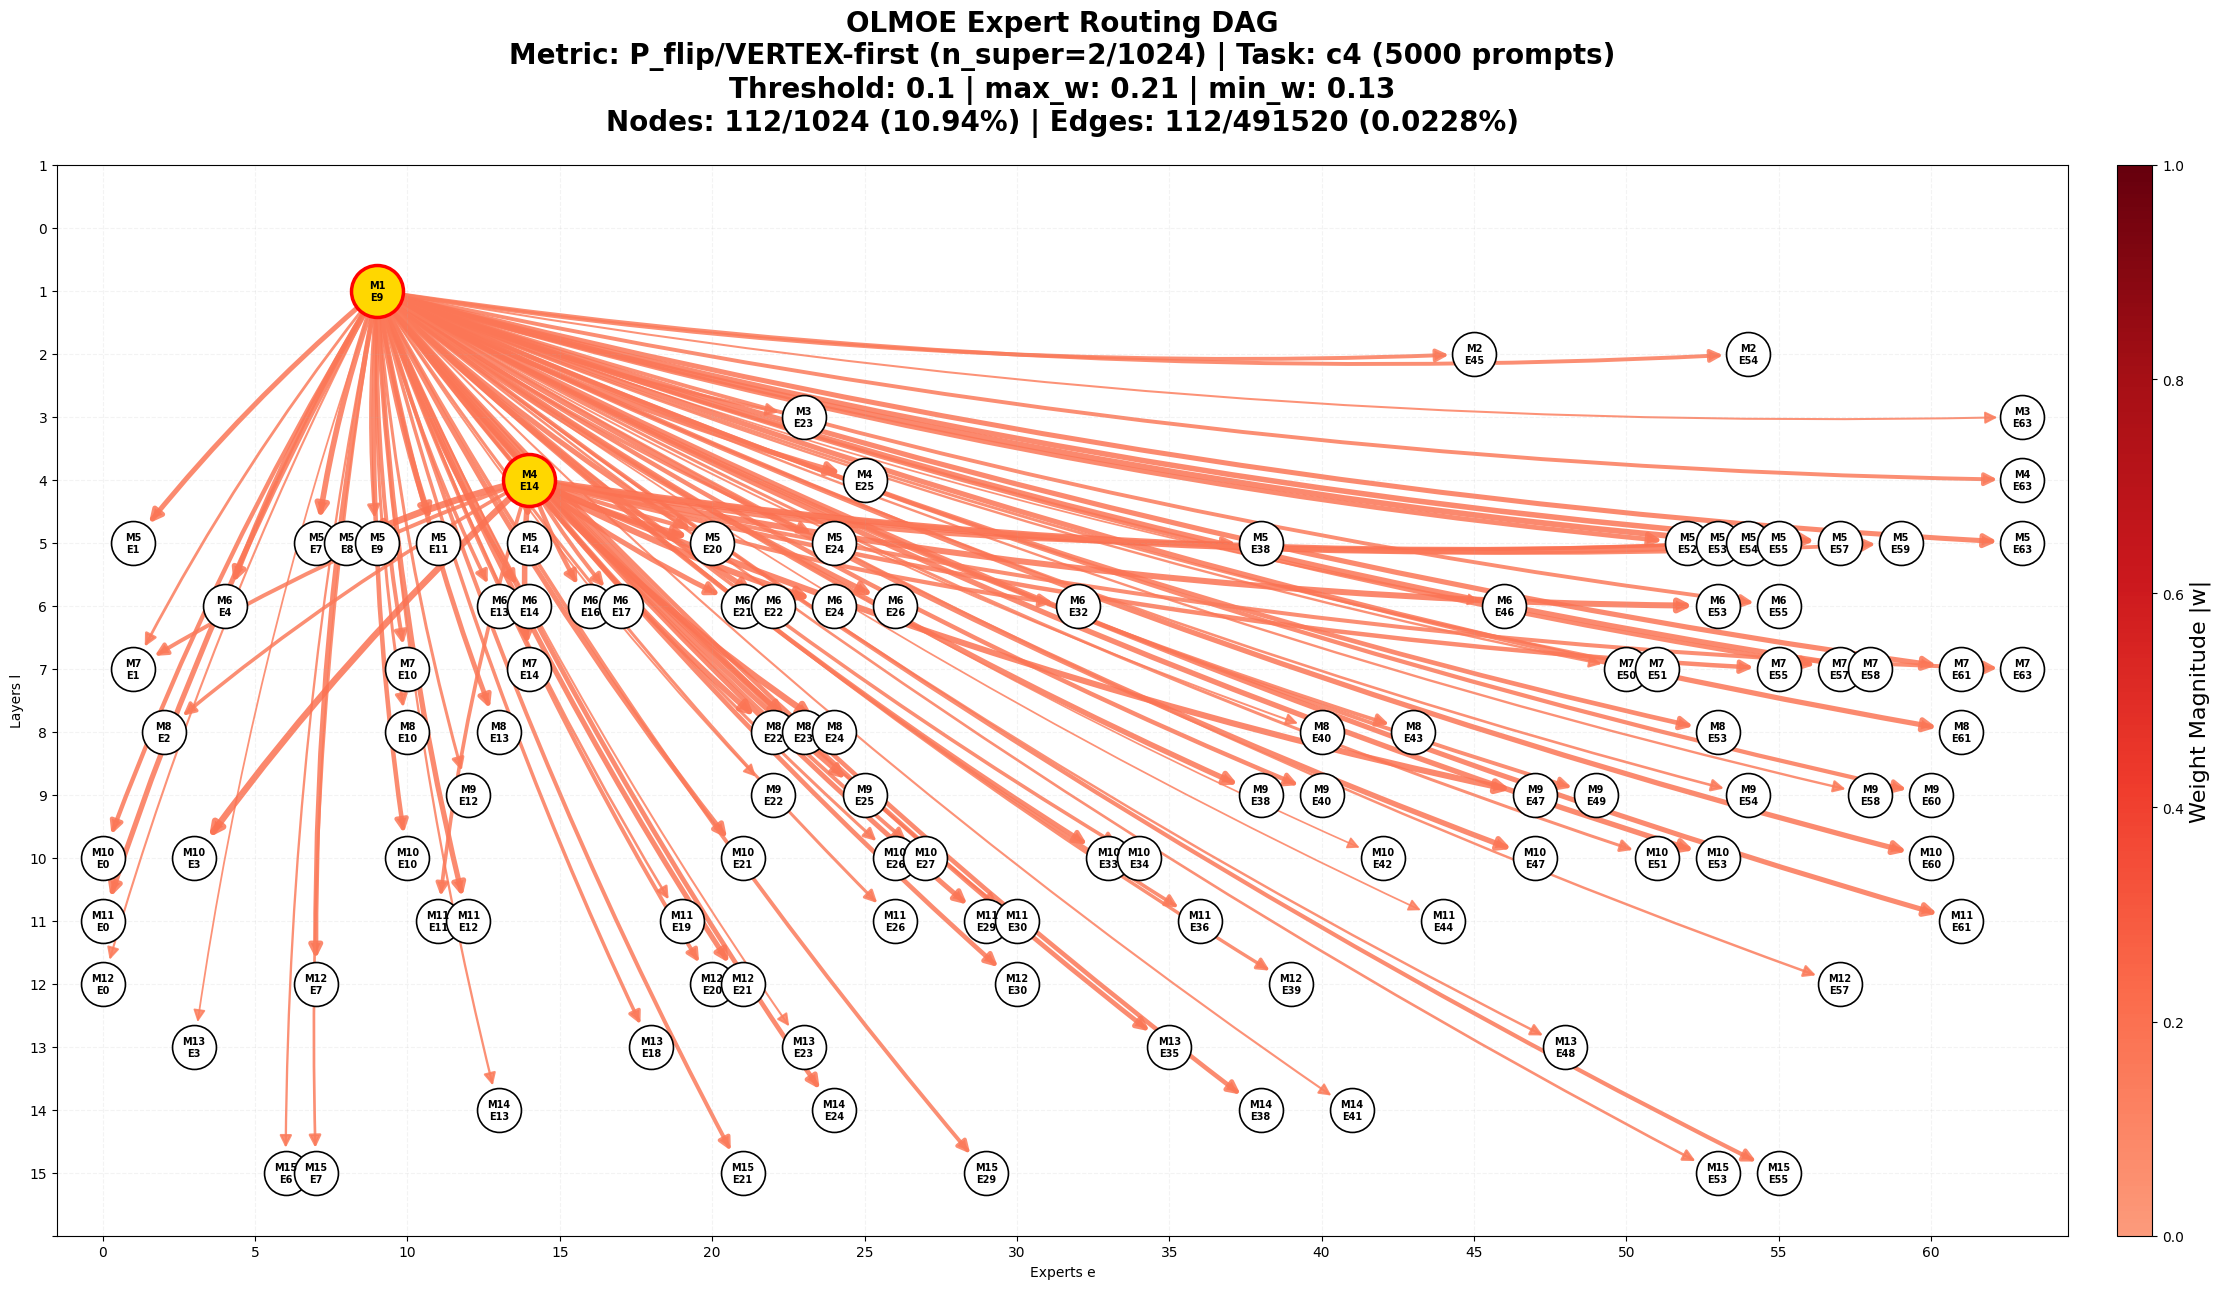

[EDGE]   olmoe: edges_kept=241/480295, t_edge=0.1009


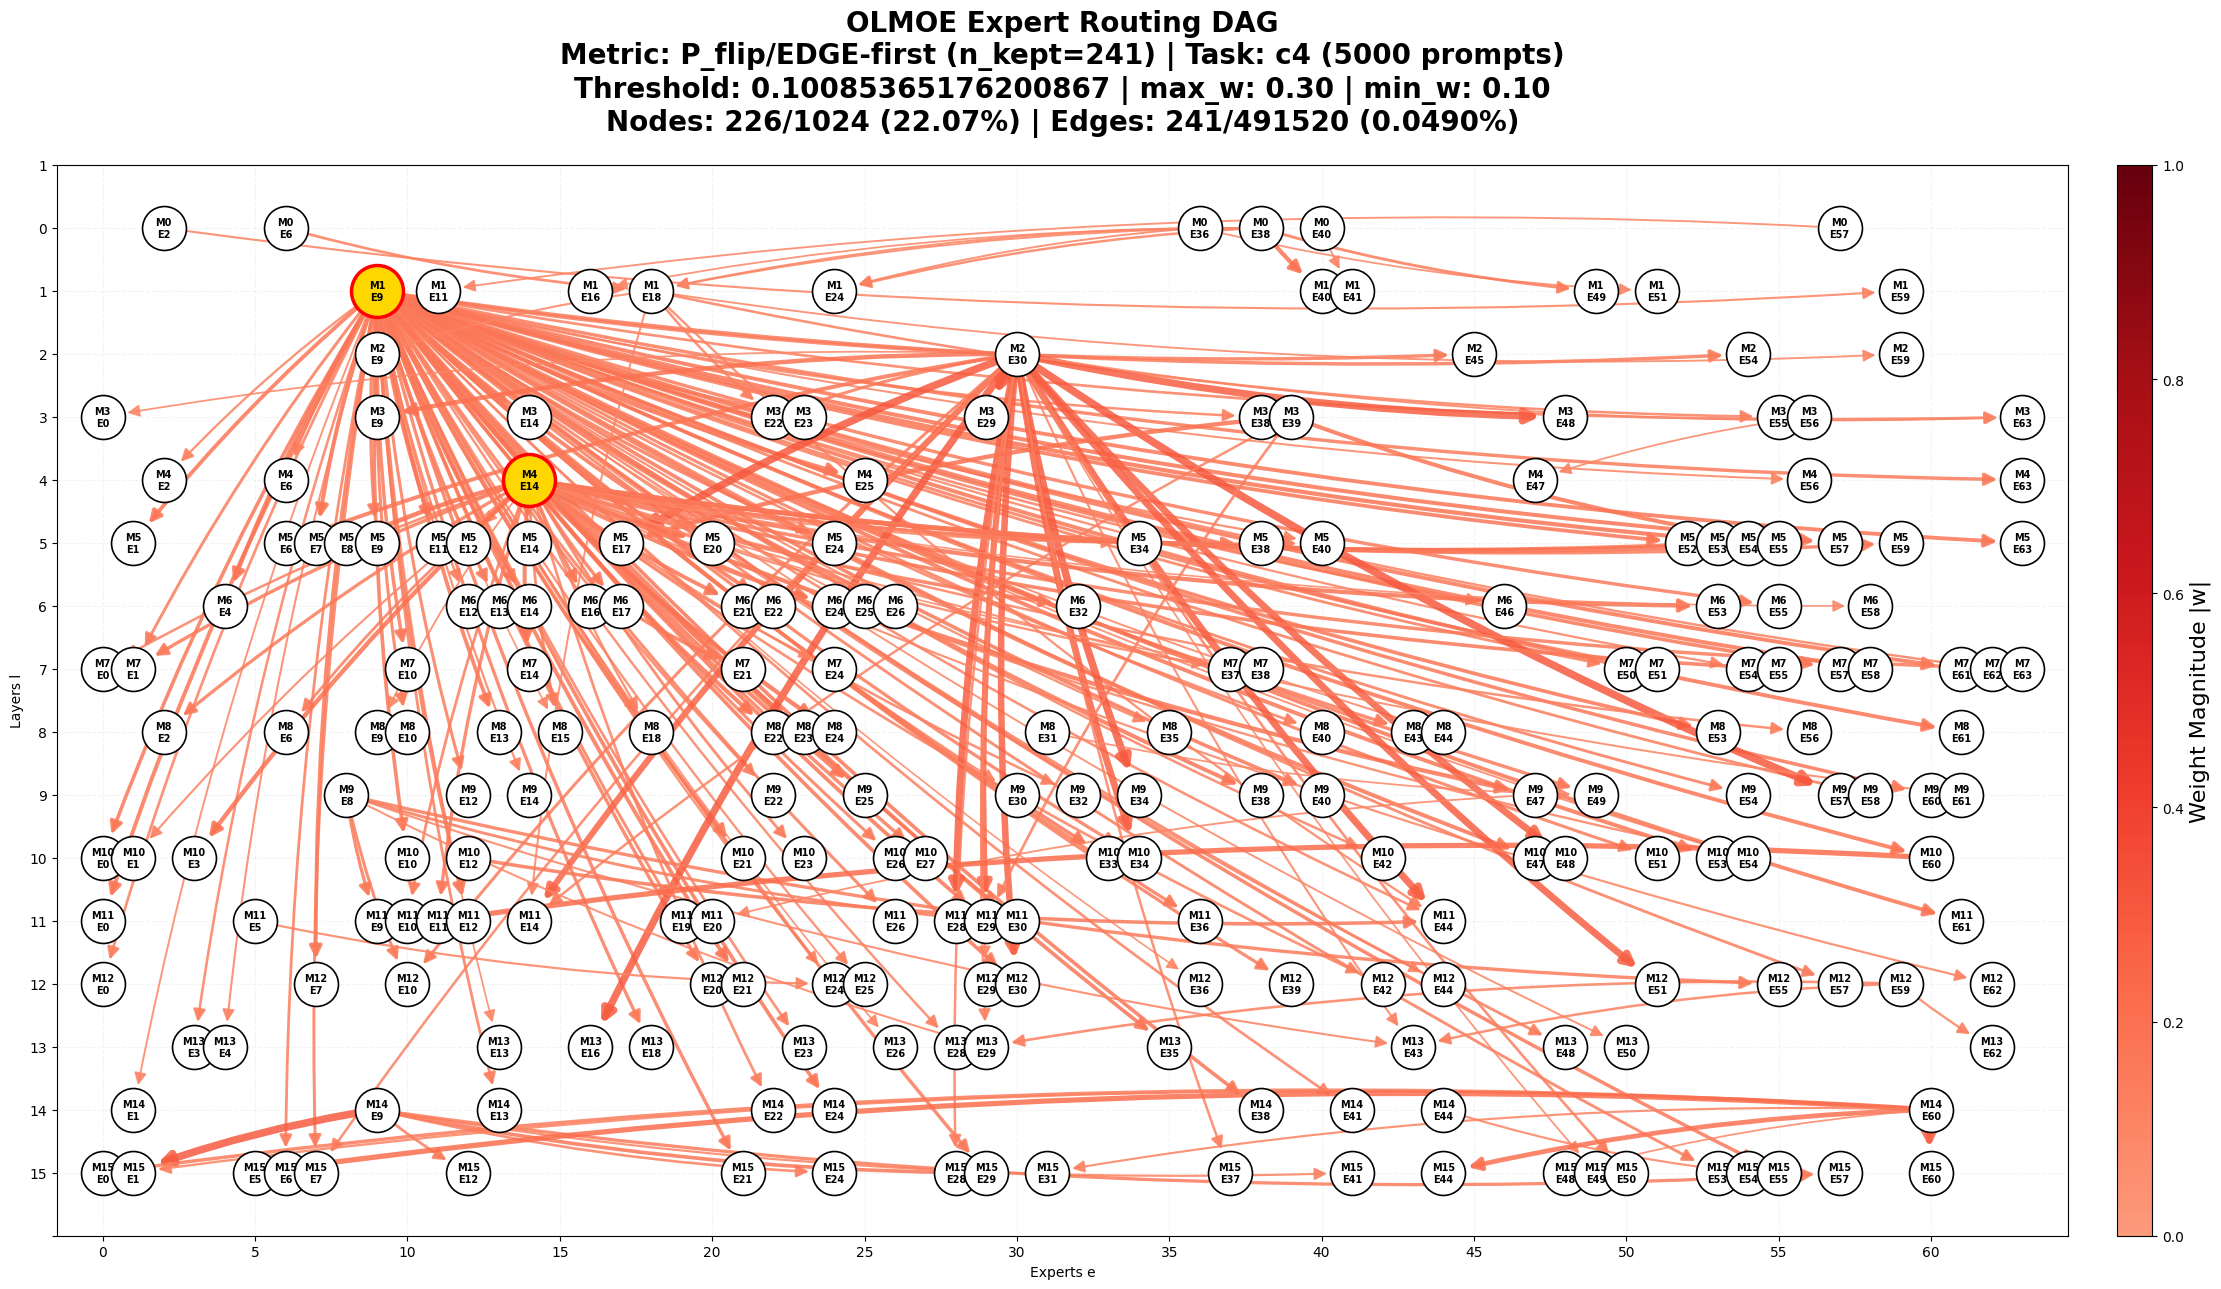

[PATHS]  olmoe: paths_edges_kept=15/241


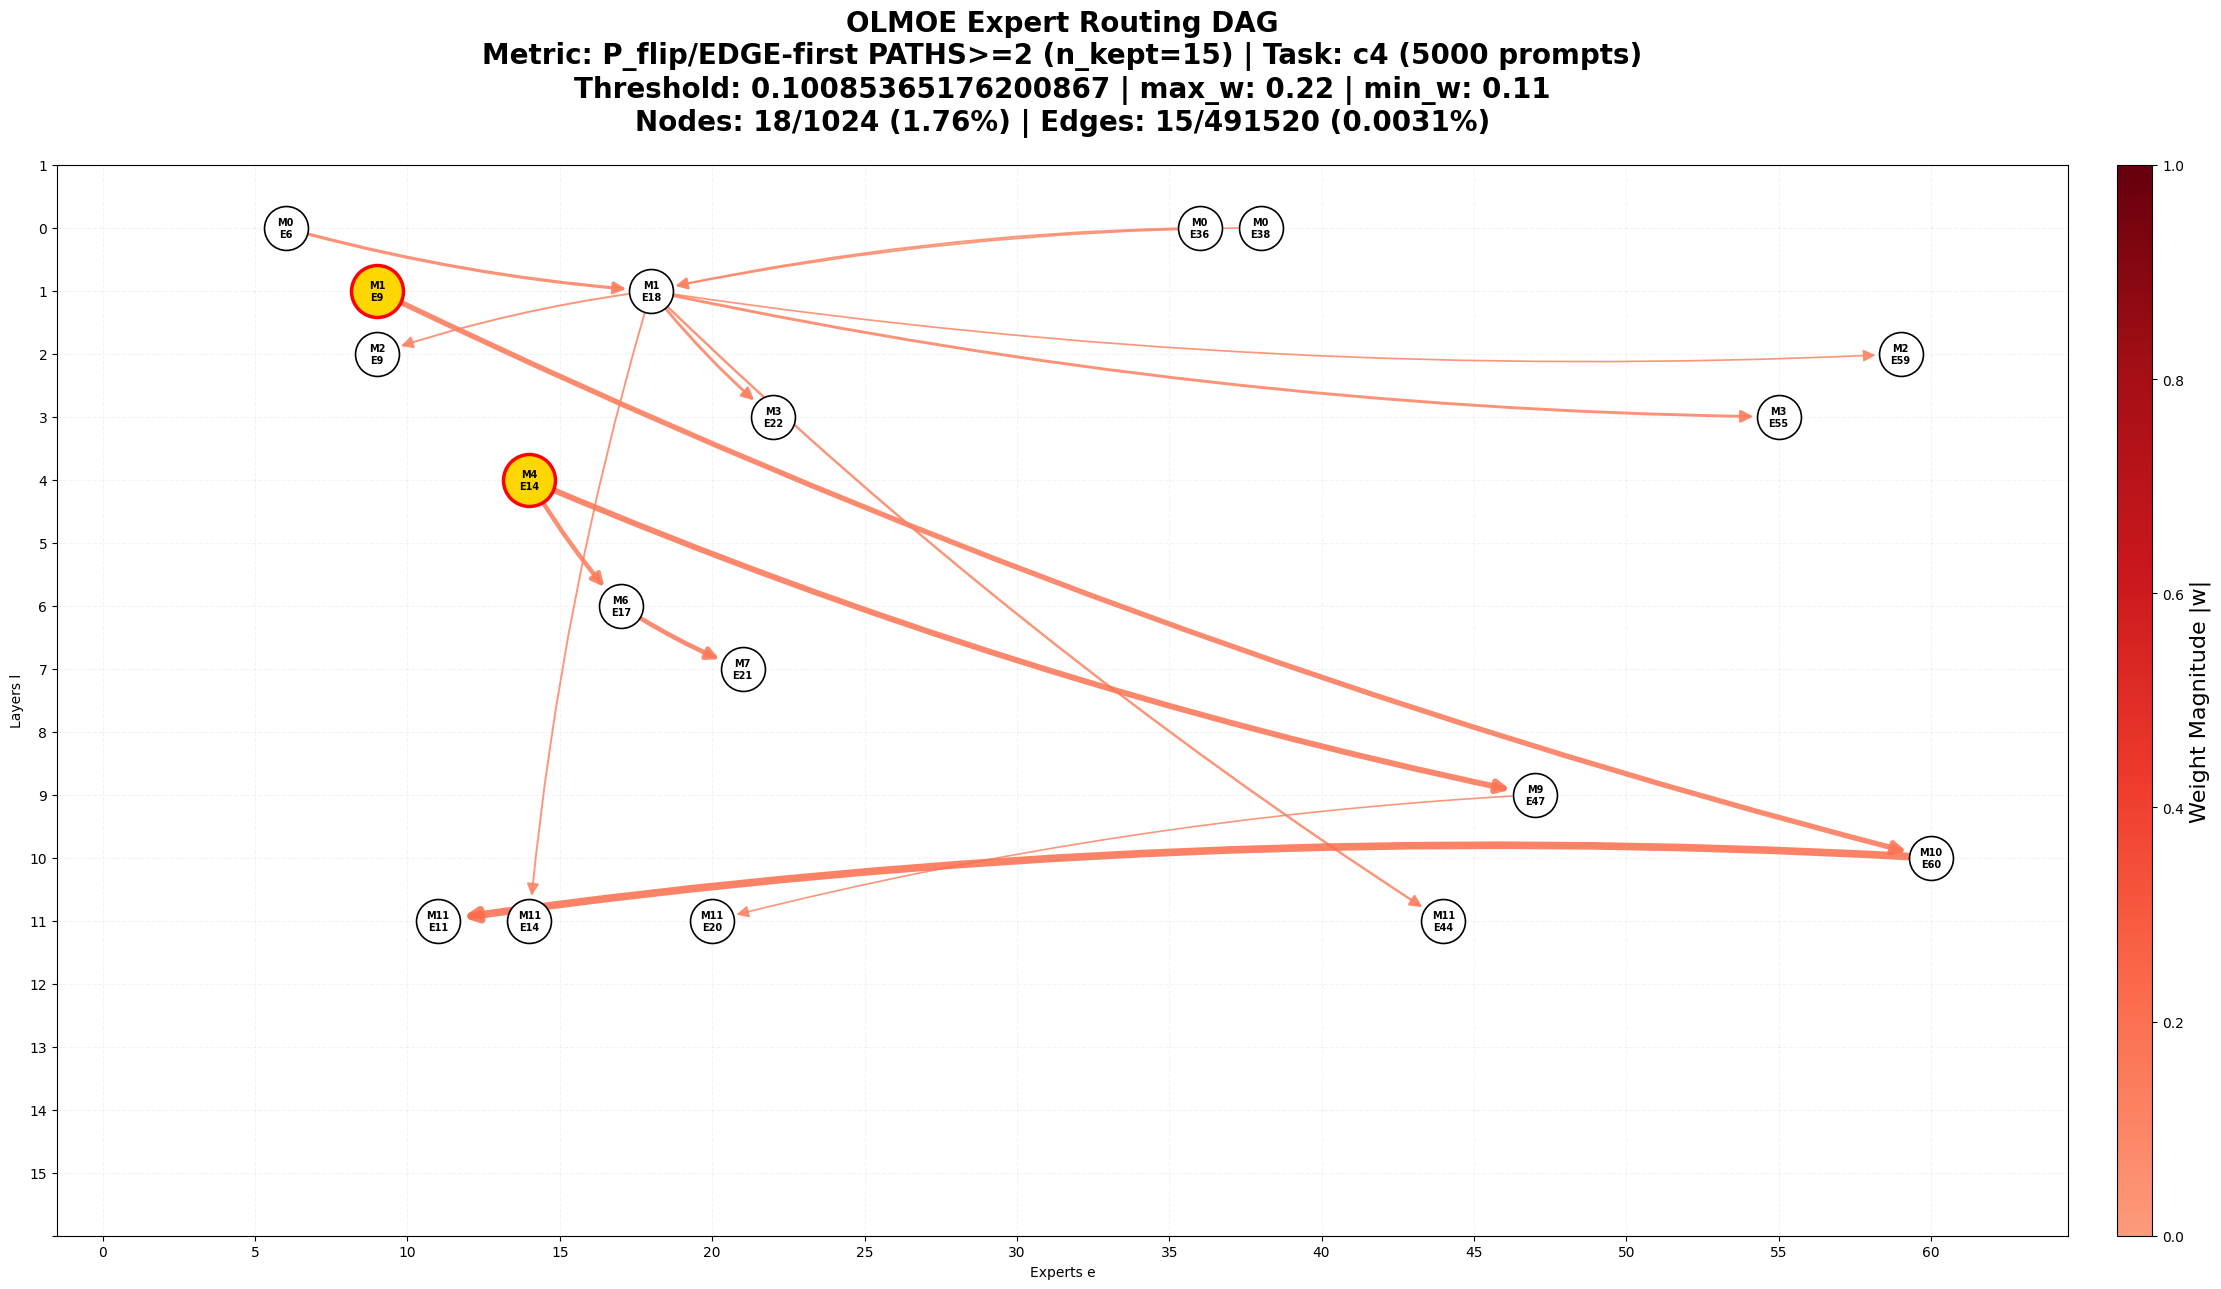

In [4]:
from experiments.circuits.helper import (
    sparsify_super_vertex, sparsify_edges, filter_to_paths,
    thresholding_routing_graph, show_enhanced_layered_graph,
)
# 'APS', 'ANS', 'AVG', 'VAR', 'AARV', 'ARV', 'P_add', 'P_rem', 'n_tokens_selected', 'top_weight', 'top_prompt', 'top_pos', 'top_token', 'k_top_tokens', 'n_prompts', 'max_tokens', 'model', 'moe_layers', 'dataset'])

# Three views per model on P_flip = P_add + P_rem.
#
# (1) VERTEX-FIRST  (sparsify_super_vertex):
#     SE on out-strength -> super-vertices, then per-vertex edge floor.
#     Answers "who is functionally important?"
#
# (2) EDGE-FIRST  (sparsify_edges):
#     SE on edge magnitudes globally. Surfaces strong connections regardless of
#     whether endpoints are super-experts.
#
# (3) EDGE-FIRST PATHS  (filter_to_paths):
#     Same as (2) but further filtered to edges that are part of a directed
#     path of length >= 2. Isolated single edges are suppressed, leaving the
#     true chain structure visible. THIS is where to look for circuits.
#
# Color axis fixed to [0, 1] (P_flip is a probability).
TARGET = "P_flip"
P_FLIP_VMIN, P_FLIP_VMAX = 0.0, 1.0

for d in DATASETS:
    for m in MODELS:
        dag = dags[(m, d)]
        if TARGET not in dag:
            dag[TARGET] = dag["P_add"] + dag["P_rem"]
        W = dag[TARGET]
        L, N = W.shape[0], W.shape[1]
        layer_labels = dag["moe_layers"]

        # ---------- (1) Vertex-first view ----------
        W_v, super_mask, vinfo = sparsify_super_vertex(
            W, 
            vertex_q=0.995, # vertex is super iff out_strength > P_99.5(out_strength)
            vertex_floor_frac=0.4, # vertex is super iff out_strength > 0.4 x max(out_strength)
            edge_floor_frac=0.7, # assume both 1. and 2. hold for v, then only keep edges s.t. |e| > 0.5 x max |e_v|
        )
        print(f"[VERTEX] {m}: n_super={vinfo['n_super']}/{L*N}, "
              f"edges_kept={vinfo['n_edges_kept']}, t_vertex={vinfo['t_vertex']:.3g}")
        dag["_vis_vertex"] = W_v
        g_v = thresholding_routing_graph(dag, "_vis_vertex", 1e-9)
        g_v.vs["is_super"] = [bool(super_mask[i // N, i % N].item()) for i in range(g_v.vcount())]
        show_enhanced_layered_graph(
            g_v, quantile=0.1,
            target=f"{TARGET}/VERTEX-first (n_super={vinfo['n_super']}/{L*N})",
            model=m, dataset=d, n_prompts=dag["n_prompts"],
            layer_labels=layer_labels,
            color_vmin=P_FLIP_VMIN, color_vmax=P_FLIP_VMAX,
        )

        # ---------- (2) Edge-first view ----------
        W_e, einfo = sparsify_edges(
            W, 
            edge_q=0.9995, # keep edges with |e| > P_99.5(all edges)
            edge_floor_frac=0.0, # keep edges with |e| > 0.1 x max(all edges)
        )
        print(f"[EDGE]   {m}: edges_kept={einfo['n_edges_kept']}/{einfo['n_edges_total']}, "
              f"t_edge={einfo['t_edge']:.4g}")
        dag["_vis_edge"] = W_e
        g_e = thresholding_routing_graph(dag, "_vis_edge", 1e-9)
        # Tag the SAME super-vertices so we can see where vertex-first super-
        # experts sit in the edge-first chain structure (overlap = corroborated;
        # divergence = hidden circuit / load-bearing expert missed by vertex-first).
        g_e.vs["is_super"] = [bool(super_mask[i // N, i % N].item()) for i in range(g_e.vcount())]
        show_enhanced_layered_graph(
            g_e, quantile=einfo['t_edge'],
            target=f"{TARGET}/EDGE-first (n_kept={einfo['n_edges_kept']})",
            model=m, dataset=d, n_prompts=dag["n_prompts"],
            layer_labels=layer_labels,
            color_vmin=P_FLIP_VMIN, color_vmax=P_FLIP_VMAX,
        )

        # ---------- (3) Edge-first paths-only view ----------
        # Drop edges that are NOT part of any directed path of length >= 2.
        # What survives is the connected backbone — the circuits.
        g_paths = filter_to_paths(g_e, min_length=3)
        print(f"[PATHS]  {m}: paths_edges_kept={g_paths.ecount()}/{g_e.ecount()}")
        show_enhanced_layered_graph(
            g_paths, quantile=einfo['t_edge'],
            target=f"{TARGET}/EDGE-first PATHS>=2 (n_kept={g_paths.ecount()})",
            model=m, dataset=d, n_prompts=dag["n_prompts"],
            layer_labels=layer_labels,
            color_vmin=P_FLIP_VMIN, color_vmax=P_FLIP_VMAX,
        )

In [ ]:
# # --- Layer-pair mass (LPM) fingerprint with RANK-TRANSFORMED weights ---
# # Cross-architecture scale issue: raw AARV magnitudes are bounded by
# # (N_EXPERTS - 1), so a value of "2" in Mixtral (8 experts -> max 7) means a
# # very different thing than in Qwen3-235B (128 experts -> max 127). Rank
# # transform replaces each edge's |W| with its percentile rank in the model's
# # own forward-edge distribution; afterward every model's edge values are
# # uniform on (0, 1] regardless of architecture.
# #
# # Note: Dividing by (N_EXPERTS - 1) is a NO-OP because LPM normalizes bucket
# # masses per-DAG; only the rank transform actually changes the analysis by
# # removing distributional-shape differences (not just scale).
# from experiments.circuits.helper import get_thresholds, layer_pair_mass, lpm_similarity
# from scipy.stats import rankdata

# WEIGHT, Q, N_BUCKETS = "AARV", 0.99, 12

# def rank_transform(W):
#     """Replace each forward-edge (s<r, |W|>0) entry's value with its percentile
#     rank within the DAG's own distribution. Output values in (0, 1]."""
#     W = W.cpu().numpy().astype(np.float64) if hasattr(W, "cpu") else np.asarray(W, dtype=np.float64)
#     L = W.shape[0]
#     s_idx = np.arange(L).reshape(-1, 1, 1, 1)
#     r_idx = np.arange(L).reshape(1, 1, -1, 1)
#     fwd = np.broadcast_to(s_idx < r_idx, W.shape)
#     valid = fwd & (np.abs(W) > 1e-9)
#     vals = np.abs(W[valid])
#     if vals.size == 0:
#         return np.zeros_like(W)
#     ranks = rankdata(vals, method="average") / vals.size
#     out = np.zeros_like(W)
#     out[valid] = ranks
#     return out

# M_dict = {}
# for key, dag in dags.items():
#     W = rank_transform(dag[WEIGHT])
#     # After rank transform, valid ranks are uniform on (0, 1].
#     # Threshold at Q directly (the q-quantile of a uniform[(0,1]] is just q).
#     Ws = np.where(W >= Q, W, 0.0)
#     M_dict[key] = layer_pair_mass(Ws, n_buckets=N_BUCKETS)


# # # Grid: rows = models, cols = datasets.
# # fig, axes = plt.subplots(len(MODELS), len(DATASETS), figsize=(11, 3.5 * len(MODELS)))
# # vmax = max(M.max() for M in M_dict.values())
# # for i, m in enumerate(MODELS):
# #     for j, d in enumerate(DATASETS):
# #         ax = axes[i, j] if len(MODELS) > 1 else axes[j]
# #         im = ax.imshow(M_dict[(m, d)], cmap="viridis", origin="upper", vmin=0, vmax=vmax)
# #         ax.set_title(f"{m}/{d}", fontsize=10)
# #         ax.set_xticks(range(N_BUCKETS)); ax.set_yticks(range(N_BUCKETS))
# #         ax.set_xlabel("receiver bucket (r/L)")
# #         ax.set_ylabel("sender bucket (s/L)")
# #         fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
# # fig.suptitle(f"LPM fingerprint (RANK-transformed {WEIGHT}, K={N_BUCKETS}, q={Q})")
# # plt.tight_layout(); plt.show()

In [ ]:
# # --- 21x21 BRD cosine similarity matrix + pairwise cross-model aggregates ---
# # Restricted to softmax+L1-normalized routing architectures (consistent application
# # of the score decomposition framework).

# n, m = len(MODELS), len(DATASETS)
# BRD_COS = np.zeros((m, n, n))
# for d, task in enumerate(DATASETS): 
#     for i, m1 in enumerate(MODELS): 
#         for j, m2 in enumerate(MODELS):  
#             BRD_COS[d, i, j] = lpm_similarity(M_dict[(m1, task)], M_dict[(m2, task)], metric="cosine")


# fig, axs = plt.subplots(1, m, figsize=(5*m, 5))
# for d, task in enumerate(DATASETS): 
#     ax = axs[d]
#     ax.set_title(f"{task}")
#     im = ax.imshow(BRD_COS[d,:,:], cmap="viridis", vmin=0.0, vmax=1.0)
#     ax.set_xticks(range(n)); ax.set_yticks(range(n))
#     ax.set_xticklabels(MODELS, rotation=45, ha="right") 
#     ax.set_yticklabels(MODELS)

#     for i in range(n):
#         for j in range(n):
#             ax.text(j, i, f"{BRD_COS[d, i, j]:.2f}", ha="center", va="center", color="white" if BRD_COS[d, i, j] < 0.5 else "black", fontsize=10)

# fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
# fig.suptitle(f"Cosine Similarity ({WEIGHT}, q={Q})")
# plt.tight_layout()
# plt.show()


# # Block aggregates: within-model (task stability) + pairwise cross-model.
# # def block_mean(M, rows, cols, exclude_diag=False):
# #     vals = [M[i, j] for i in rows for j in cols if not (exclude_diag and i == j)]
# #     return float(np.mean(vals)) if vals else float("nan")

# # model_idx = {m: [i for i, k in enumerate(keys) if k[0] == m] for m in MODELS}

# # print(f"--- BRD cosine  (K={N_BUCKETS}, sparsified {WEIGHT}, q={Q}) ---")
# # print("  Within-model (task stability):")
# # for m in MODELS:
# #     wm = block_mean(BRD_COS, model_idx[m], model_idx[m], exclude_diag=True)
# #     print(f"    WM[{m:<18s}] = {wm:.3f}")
# # print("  Cross-model (CMS = same-dataset, CMD = different-dataset):")
# # pairs = [(MODELS[a], MODELS[b]) for a in range(len(MODELS)) for b in range(a + 1, len(MODELS))]
# # for m_a, m_b in pairs:
# #     idx_a, idx_b = model_idx[m_a], model_idx[m_b]
# #     CMS = float(np.mean([BRD_COS[i, j] for i in idx_a for j in idx_b if keys[i][1] == keys[j][1]]))
# #     CMD = float(np.mean([BRD_COS[i, j] for i in idx_a for j in idx_b if keys[i][1] != keys[j][1]]))
# #     print(f"    {m_a:<18s} <-> {m_b:<18s}  CMS={CMS:.3f}  CMD={CMD:.3f}")

In [ ]:
# # --- Sparsification sweep: how do cross-model alignment + task stability vary with Q? ---
# # Diagnostic for metric robustness. If pair rankings reorder dramatically as Q varies,
# # the LPM metric is unreliable as a similarity measure. If curves are roughly parallel
# # across a wide Q range, that's the stable regime we should report.
# Q_VALUES = [0.5, 0.8, 0.9, 0.95, 0.99, 0.999, 0.9999]

# pair_keys = [(MODELS[a], MODELS[b]) for a in range(len(MODELS)) for b in range(a + 1, len(MODELS))]
# CMS_curves = {p: [] for p in pair_keys}
# CMD_curves = {p: [] for p in pair_keys}
# WM_curves  = {m: [] for m in MODELS}

# for Q_s in Q_VALUES:
#     M_dict_s = {}
#     for key, dag in dags.items():
#         W = dag[WEIGHT]
#         if isinstance(W, torch.Tensor):
#             W = W.cpu().numpy().astype(np.float64)
#         t = get_thresholds(dag, WEIGHT, [Q_s])[Q_s]
#         Ws = np.where(np.abs(W) >= t, W, 0.0)
#         M_dict_s[key] = layer_pair_mass(Ws, n_buckets=N_BUCKETS)
#     SIM_s = np.zeros((n, n))
#     for i in range(n):
#         for j in range(n):
#             SIM_s[i, j] = lpm_similarity(M_dict_s[keys[i]], M_dict_s[keys[j]], metric="cosine")
#     for m in MODELS:
#         WM_curves[m].append(block_mean(SIM_s, model_idx[m], model_idx[m], exclude_diag=True))
#     for (m_a, m_b) in pair_keys:
#         idx_a, idx_b = model_idx[m_a], model_idx[m_b]
#         CMS_curves[(m_a, m_b)].append(
#             float(np.mean([SIM_s[i, j] for i in idx_a for j in idx_b if keys[i][1] == keys[j][1]])))
#         CMD_curves[(m_a, m_b)].append(
#             float(np.mean([SIM_s[i, j] for i in idx_a for j in idx_b if keys[i][1] != keys[j][1]])))

# # Plot 1: cross-model CMS as a function of Q (6 pairs).
# # Plot 2: within-model WM as a function of Q (4 models).
# fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))
# x = np.arange(len(Q_VALUES))

# short_pair = lambda p: f"{short[p[0]]} ↔ {short[p[1]]}"
# ax = axes[0]
# for p in pair_keys:
#     ax.plot(x, CMS_curves[p], marker="o", linewidth=2, label=short_pair(p))
# ax.set_xticks(x); ax.set_xticklabels([str(q) for q in Q_VALUES])
# ax.set_xlabel("sparsification quantile Q")
# ax.set_ylabel("cross-model CMS (cosine of LPM)")
# ax.set_ylim(0, 1.05)
# ax.legend(fontsize=8, ncol=2, loc="lower left")
# ax.grid(alpha=0.3)
# ax.set_title(f"Cross-model alignment vs Q ({WEIGHT}, K={N_BUCKETS})")

# ax = axes[1]
# for m in MODELS:
#     ax.plot(x, WM_curves[m], marker="o", linewidth=2, label=short[m])
# ax.set_xticks(x); ax.set_xticklabels([str(q) for q in Q_VALUES])
# ax.set_xlabel("sparsification quantile Q")
# ax.set_ylabel("within-model WM (cosine of LPM)")
# ax.set_ylim(0, 1.05)
# ax.legend(fontsize=9)
# ax.grid(alpha=0.3)
# ax.set_title(f"Within-model task stability vs Q ({WEIGHT}, K={N_BUCKETS})")

# plt.tight_layout(); plt.show()

# # Numeric output.
# print(f"Q values:  {' '.join(f'{q:>7g}' for q in Q_VALUES)}")
# print(f"\nCross-model CMS:")
# for p in pair_keys:
#     vals = " ".join(f"{v:>7.3f}" for v in CMS_curves[p])
#     print(f"  {short_pair(p):<14s} {vals}")
# print(f"\nCross-model CMS − CMD  (Platonic per-task signal; ~0 means no per-task alignment):")
# for p in pair_keys:
#     diffs = [c - d for c, d in zip(CMS_curves[p], CMD_curves[p])]
#     vals = " ".join(f"{v:>+7.3f}" for v in diffs)
#     print(f"  {short_pair(p):<14s} {vals}")
# print(f"\nWithin-model WM:")
# for m in MODELS:
#     vals = " ".join(f"{v:>7.3f}" for v in WM_curves[m])
#     print(f"  {short[m]:<6s}        {vals}")

In [ ]:
from transformers import AutoTokenizer
model_dict = {
    "olmoe": "allenai/OLMoE-1B-7B-0924", 
    "deepseek-v2-lite": "deepseek-ai/DeepSeek-V2-Lite"
}

for m, id in model_dict.items():
    n_tok = dags[(m, "c4")]["n_tokens_selected"]  # [L, N]
    L, N = n_tok.shape
    total_global  = n_tok.sum().item()
    total_per_lyr = n_tok.sum(dim=1)  # [L]
    top10 = torch.topk(n_tok.flatten(), 1000)

    tok = dags[(m, "c4")]["top_token"]
    tokenizer = AutoTokenizer.from_pretrained(id)

    print(f"\n{m.upper()}")
    print(f"{'rank':>4s}  {'expert':>9s}  {'n_tokens':>9s}  {'global':>7s}  {'in-layer':>8s}  {'tokens'}")
    for rank, (val, idx) in enumerate(zip(top10.values.tolist(), top10.indices.tolist()), 1):
        layer, expert = idx // N, idx % N
        global_share = val / total_global
        layer_share  = val / total_per_lyr[layer].item()
        top_tokens = [repr(tokenizer.decode([t.item()])) for t in tok[layer, expert, :10]]
        print(f"  {rank:>4d}  {f'M{layer}E{expert}':>9s}  {val:>9d}  {global_share:>7.2%}  {layer_share:>8.2%}  {top_tokens}")

In [ ]:
# Cross-model semantic analysis of super-experts (c4).
#
# Pipeline (matches the viz cell exactly so the printed super-expert set is the
# same as the gold-highlighted nodes in the graph):
#   1. Per model, compute out_strength[c, j] = sum_{l>c, n} P_flip(c, j -> l, n).
#   2. SE double-criterion -> super-vertex set.
#   3. List sorted by out_strength desc. For each: token load, layer/global rank,
#      sink_frac (fraction of top-buffer events at sequence position 0; diagnoses
#      attention-sink / first-token specialization which differs qualitatively
#      from content-token routing and is not directly comparable across models
#      with different tokenizer BOS conventions), and the top-K unique tokens.
#
# Display labels use dag["moe_layers"] so DeepSeek-V2-Lite shows model layer
# numbers (M3, M4, ...) matching the SE paper, not internal MoE-only indices.
from transformers import AutoTokenizer
from collections import Counter

TOKENIZER_IDS = {
    "olmoe":            "allenai/OLMoE-1B-7B-0924",
    "deepseek-v2":      "deepseek-ai/DeepSeek-V2",
    "deepseek-v2-lite": "deepseek-ai/DeepSeek-V2-Lite",
    "mixtral-8x7b":     "mistralai/Mixtral-8x7B-v0.1",
    "mixtral-8x22b":    "mistralai/Mixtral-8x22B-v0.1",
    "qwen3-30b-a3b":    "Qwen/Qwen3-30B-A3B",
    "qwen3-235b-a22b":  "Qwen/Qwen3-235B-A22B",
    "phi-3.5-moe":      "microsoft/Phi-3.5-MoE-instruct",
}
TOKENIZERS = {m: AutoTokenizer.from_pretrained(TOKENIZER_IDS[m])
              for m in MODELS if m in TOKENIZER_IDS}

SE_VERTEX_Q = 0.995  # match viz cell exactly
K_SHOW      = 20      # number of unique tokens per expert to print


def _ranks(n_tok, layer, expert):
    val = n_tok[layer, expert].item()
    layer_rank  = int((n_tok[layer]    > val).sum().item()) + 1
    global_rank = int((n_tok.flatten() > val).sum().item()) + 1
    return layer_rank, global_rank


for m in MODELS:
    if m not in TOKENIZERS:
        print(f"--- {m}: no tokenizer registered, skipping ---")
        continue
    dag = dags[(m, "c4")]
    W = dag["P_flip"] if "P_flip" in dag else (dag["P_add"] + dag["P_rem"])
    L, N = W.shape[0], W.shape[1]
    moe_layers = dag["moe_layers"]  # internal idx -> model layer

    # Out-strength on forward edges.
    s_idx = torch.arange(L).view(-1, 1, 1, 1)
    r_idx = torch.arange(L).view(1, 1, -1, 1)
    fwd = (s_idx < r_idx).expand_as(W)
    W_abs = torch.abs(W.float())
    out_strength = (W_abs * fwd.float()).sum(dim=(2, 3))            # [L, N]

    # SE double-criterion -> super-vertex set.
    os_vals  = out_strength[out_strength > 1e-9].cpu().numpy()
    t_vertex = max(float(np.quantile(os_vals, SE_VERTEX_Q)),
                   float(0.4 * os_vals.max()))
    super_mask = out_strength > t_vertex                              # [L, N] bool

    # Sort super-experts by out-strength descending.
    super_idx = torch.nonzero(super_mask, as_tuple=False)             # [n_super, 2]
    order     = torch.argsort(out_strength[super_mask], descending=True)
    super_idx = super_idx[order]

    n_tok     = dag["n_tokens_selected"]
    tok_buf   = dag["top_token"]
    pos_buf   = dag["top_pos"]
    w_buf     = dag["top_weight"]
    K_BUF     = tok_buf.shape[-1]
    tokenizer = TOKENIZERS[m]

    print(f"\n=================================================================")
    print(f"  {m.upper()}  --  {super_idx.shape[0]} super-experts  "
          f"(SE Q={SE_VERTEX_Q}, t_vertex={t_vertex:.4g})")
    print(f"=================================================================")
    i = 0
    for rank, (layer, expert) in enumerate(super_idx.tolist(), 1):
        if i == 10: break
        r_layer, r_global = _ranks(n_tok, layer, expert)
        os_val = float(out_strength[layer, expert].item())
        mask   = w_buf[layer, expert] > 0
        ids    = tok_buf[layer, expert][mask].tolist()
        positions = pos_buf[layer, expert][mask].tolist()
        sink_frac = (sum(1 for p in positions if p == 0) / len(positions)) if positions else 0.0
        counts = Counter(ids).most_common(K_SHOW)
        overload = n_tok[layer, expert] / (n_tok[layer].sum() / N)
        tok_strs = [f"{repr(tokenizer.decode([tid]))} x{c}" for tid, c in counts]
        print(f"  #{rank:>2d}  M{moe_layers[layer]}E{expert}:  "
              f"out_strength={os_val:.2f}  "
              f"overload={overload:.2f}  "
              f"layer-rank={r_layer}/{N}  global-rank={r_global}/{L*N}  "
              f"sink_frac={sink_frac:.0%}  "
              f"({len(ids)}/{K_BUF} slots, {len(Counter(ids))} unique)")
        print(f"        top {K_SHOW} unique: {', '.join(tok_strs)}")
        i += 1

In [ ]:
# Distribution of per-edge |P_flip| values per model.
# Both axes are log so the heavy tail on the right is readable instead of being
# squashed by the bulk near zero. Reference lines: percentile cutoffs (red) and
# the max/10 floor (green).
TARGET = "P_flip"

n_models = len(MODELS)
n_cols   = min(4, n_models)
n_rows   = (n_models + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 4 * n_rows))
axes = np.array(axes).flatten()

BAR_COLOR   = "#4C72B0"
BAR_EDGE    = "#2F4D75"
LINE_COLOR  = "#C44E52"
FLOOR_COLOR = "#55A868"

for ax, m in zip(axes, MODELS):
    dag = dags[(m, "c4")]
    W = dag["P_flip"] if "P_flip" in dag else (dag["P_add"] + dag["P_rem"])
    L, N = W.shape[0], W.shape[1]

    s_idx = torch.arange(L).view(-1, 1, 1, 1)
    r_idx = torch.arange(L).view(1, 1, -1, 1)
    fwd = (s_idx < r_idx).expand_as(W)
    edge_vals = torch.abs(W[fwd].float())
    edge_vals = edge_vals[edge_vals > 1e-9].cpu().numpy()
    max_v = float(edge_vals.max())

    # Log-spaced bins so the heavy tail isn't smashed against the right edge.
    bins = np.logspace(np.log10(edge_vals.min()), np.log10(max_v), 80)
    ax.hist(edge_vals, bins=bins, log=True,
            color=BAR_COLOR, edgecolor=BAR_EDGE, linewidth=0.4, alpha=0.85)
    ax.set_xscale("log")

    for q, ls in [(0.9, ":"), (0.99, "--"), (0.999, "-."), (0.9999, "-")]:
        qv = float(np.quantile(edge_vals, q))
        ax.axvline(qv, color=LINE_COLOR, linestyle=ls, linewidth=1.3, alpha=0.9,
                   label=f"P_{q*100:g}")
    ax.axvline(max_v / 10, color=FLOOR_COLOR, linestyle="-", linewidth=2, alpha=0.9,
               label="max/10")

    ax.set_title(f"{m}\n{len(edge_vals):,d} edges  •  max={max_v:.3f}", fontsize=9)
    ax.set_xlabel(f"edge magnitude  |{TARGET}|  (log)")
    ax.set_ylabel("# edges per bin  (log)")
    ax.legend(fontsize=6, loc="upper left")
    ax.grid(alpha=0.25, which="both")

for ax in axes[n_models:]:
    ax.set_visible(False)

plt.suptitle(f"Edge-magnitude distribution ({TARGET}, forward edges only)", fontsize=12)
plt.tight_layout()
plt.show()

In [ ]:
# Distribution of per-expert out_strength = sum_{l>c, n} P_flip(c, j -> l, n).
# Log-log axes so the heavy tail (where super-experts live) is readable. The
# top-3 experts per model are labeled with M{layer}E{expert}. HIGHLIGHTS_BY_MODEL
# additionally marks specific experts of interest in orange (use this to locate
# a hypothesized super-expert in the distribution).
TARGET = "P_flip"

n_models = len(MODELS)
n_cols   = min(4, n_models)
n_rows   = (n_models + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 4 * n_rows))
axes = np.array(axes).flatten()

BAR_COLOR       = "#4C72B0"
BAR_EDGE        = "#2F4D75"
LINE_COLOR      = "#C44E52"
FLOOR_COLOR     = "#55A868"
HIGHLIGHT_COLOR = "#E67E22"   # orange for manual highlights

TOP_N_LABEL = 3
# Per-model manual highlights: list of (internal_layer_idx, expert_idx) tuples
# to mark in addition to the auto top-3.
HIGHLIGHTS_BY_MODEL = {
    "qwen3-30b-a3b": [(1, 68)],
}

for ax, m in zip(axes, MODELS):
    dag = dags[(m, "c4")]
    W = dag["P_flip"] if "P_flip" in dag else (dag["P_add"] + dag["P_rem"])
    L, N = W.shape[0], W.shape[1]
    moe_layers_arr = dag["moe_layers"]

    s_idx = torch.arange(L).view(-1, 1, 1, 1)
    r_idx = torch.arange(L).view(1, 1, -1, 1)
    fwd = (s_idx < r_idx).expand_as(W)
    out_strength = (torch.abs(W.float()) * fwd.float()).sum(dim=(2, 3))   # [L, N]
    os_flat = out_strength.flatten()
    os_vals = os_flat[os_flat > 1e-9].cpu().numpy()
    max_v = float(os_vals.max())

    bins = np.logspace(np.log10(os_vals.min()), np.log10(max_v), 60)
    ax.hist(os_vals, bins=bins, log=True,
            color=BAR_COLOR, edgecolor=BAR_EDGE, linewidth=0.4, alpha=0.85)
    ax.set_xscale("log")

    for q, ls in [(0.9, ":"), (0.99, "--"), (0.995, "-."), (0.999, "-")]:
        qv = float(np.quantile(os_vals, q))
        ax.axvline(qv, color=LINE_COLOR, linestyle=ls, linewidth=1.3, alpha=0.9,
                   label=f"P_{q*100:g}")
    ax.axvline(max_v / 10, color=FLOOR_COLOR, linestyle="-", linewidth=2, alpha=0.9,
               label="max/10")

    trans = ax.get_xaxis_transform()  # x in data coords, y in axes fraction

    # Auto top-3 labels.
    top = torch.topk(os_flat, TOP_N_LABEL)
    for k_, (strength, fidx) in enumerate(zip(top.values.tolist(), top.indices.tolist())):
        layer = fidx // N
        expert = fidx % N
        label = f"M{moe_layers_arr[layer]}E{expert}"
        y_frac = 0.95 - k_ * 0.08
        ax.annotate(
            label,
            xy=(strength, 0.0), xycoords=trans,
            xytext=(strength, y_frac), textcoords=trans,
            fontsize=7, ha="center", va="top",
            arrowprops=dict(arrowstyle="-", color="#333", lw=0.5, alpha=0.6),
            bbox=dict(boxstyle="round,pad=0.2", fc="white", ec="#333", lw=0.4, alpha=0.95),
        )

    # Manual highlights (orange, mid-plot label, vertical guide line).
    for (layer, expert) in HIGHLIGHTS_BY_MODEL.get(m, []):
        strength = float(out_strength[layer, expert].item())
        label = f"M{moe_layers_arr[layer]}E{expert}"
        ax.axvline(strength, color=HIGHLIGHT_COLOR, linestyle="-", linewidth=1.5, alpha=0.7)
        ax.annotate(
            label,
            xy=(strength, 0.0), xycoords=trans,
            xytext=(strength, 0.5), textcoords=trans,
            fontsize=8, ha="center", va="top", fontweight="bold",
            color=HIGHLIGHT_COLOR,
            arrowprops=dict(arrowstyle="-", color=HIGHLIGHT_COLOR, lw=0.8, alpha=0.8),
            bbox=dict(boxstyle="round,pad=0.25", fc="white",
                      ec=HIGHLIGHT_COLOR, lw=0.8, alpha=0.95),
        )

    ax.set_title(f"{m}\n{len(os_vals)} experts  •  max={max_v:.2f}", fontsize=9)
    ax.set_xlabel(f"expert mass  (sum outgoing |{TARGET}|)  (log)")
    ax.set_ylabel("# experts per bin  (log)")
    ax.legend(fontsize=6, loc="upper left")
    ax.grid(alpha=0.25, which="both")

for ax in axes[n_models:]:
    ax.set_visible(False)

plt.suptitle(f"Per-expert out-strength distribution ({TARGET}, forward edges only)", fontsize=12)
plt.tight_layout()
plt.show()

In [ ]:
# Top-K expert masses per model (table).
# Rows: models.  Cols: #experts (L*N), out_strength of Top-1..Top-10 (descending
# mass), plus a `Top1 * 0.4` column = 40%-of-max threshold candidate.
TARGET = "P_flip"
RANKS  = list(range(1, 11))

NAME_W = 20    # model name column
NUM_W  = 8     # #experts column
COL_W  = 10    # all numeric columns (TopK + Top1*0.4)
FLOOR_LABEL = "Top1 * 0.4"

header_parts = [f"{'Model':<{NAME_W}s}", f"{'#Experts':>{NUM_W}s}"]
header_parts += [f"{'Top'+str(r):>{COL_W}s}" for r in RANKS]
header_parts += [f"{FLOOR_LABEL:>{COL_W}s}"]
header = "  ".join(header_parts)
print(header)
print("-" * len(header))

for m in MODELS:
    dag = dags[(m, "c4")]
    W = dag["P_flip"] if "P_flip" in dag else (dag["P_add"] + dag["P_rem"])
    L, N = W.shape[0], W.shape[1]

    s_idx = torch.arange(L).view(-1, 1, 1, 1)
    r_idx = torch.arange(L).view(1, 1, -1, 1)
    fwd = (s_idx < r_idx).expand_as(W)
    out_strength = (torch.abs(W.float()) * fwd.float()).sum(dim=(2, 3))   # [L, N]

    top_vals = torch.topk(out_strength.flatten(), max(RANKS)).values.tolist()
    floor    = 0.4 * top_vals[0]

    row_parts = [f"{m:<{NAME_W}s}", f"{L*N:>{NUM_W}d}"]
    row_parts += [f"{top_vals[r-1]:>{COL_W}.3f}" for r in RANKS]
    row_parts += [f"{floor:>{COL_W}.3f}"]
    print("  ".join(row_parts))